In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.listdir()

['.ipynb_checkpoints',
 'BUSINESS ANALYSIS TASK LIST.pdf',
 'Telco_Customer_Churn_Analysis.html',
 'Telco_Customer_Churn_Analysis.ipynb',
 'Telco_Customer_Churn_Dataset  (3).xlsx']

In [3]:
df = pd.read_excel("Telco_Customer_Churn_Dataset  (3).xlsx")

# Task 1: Dataset Understanding

## Objective
Understand the dataset and identify potential data quality issues.

In [4]:
df.shape


(7043, 21)

In [5]:
df.head(10)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Observation

The dataset contains customer demographic information, service details, billing information, and churn status. Both numerical and categorical features are present for analysis.


# Task 2: Data Cleaning

## Objective

Identify and resolve data quality issues such as missing values and duplicate records to ensure accurate analysis.

In [7]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [8]:
df.isnull().sum().sum() 

11

### Observation

A total of 11 missing values were identified in the dataset. All missing values were found in the `TotalCharges` column. Further investigation revealed that these records belong to customers with a tenure of 0 months, indicating that they are newly joined customers and have not accumulated any total charges yet.

In [9]:
df['TotalCharges']=df['TotalCharges'].fillna(0)

### Observation

The `TotalCharges` column contained 11 missing values. Analysis showed that these records belonged to customers with a tenure of 0 months. Since these customers had not completed a billing cycle, their total charges were not available. Therefore, the missing values were replaced with 0 to maintain data consistency and avoid losing records during analysis.

In [10]:
df.isnull().sum().sum()

0

### Observation

All missing values have been successfully handled.

In [11]:
df = df.drop_duplicates()

In [12]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
df.columns = [
    'customer_id',
    'gender',
    'senior_citizen',
    'partner',
    'dependents',
    'tenure',
    'phone_service',
    'multiple_lines',
    'internet_service',
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies',
    'contract',
    'paperless_billing',
    'payment_method',
    'monthly_charges',
    'total_charges',
    'churn'
]

In [14]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Task 3: Exploratory Data Analysis (EDA)

## Objective

Analyze the dataset using descriptive statistics and visualizations to identify patterns, trends, and factors associated with customer churn.

In [15]:
df[['tenure','monthly_charges','total_charges']].describe()

,tenure,monthly_charges,total_charges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


### Observation

The average customer tenure is approximately 32 months, while the average monthly charge is around 65. The dataset contains both short-term and long-term customers.

<function matplotlib.pyplot.show(close=None, block=None)>

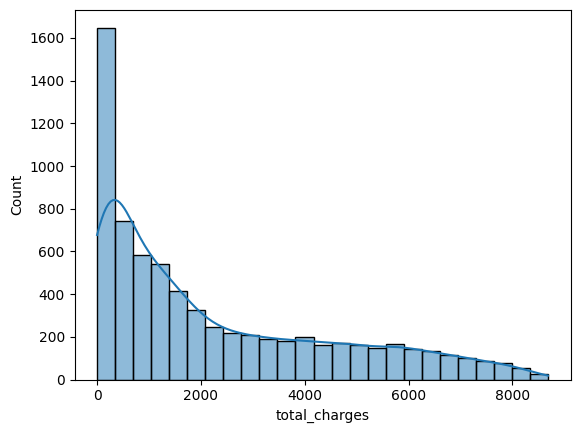

In [16]:
sns.histplot(x=df['total_charges'],kde=True)
plt.show

### Observation

The TotalCharges distribution is positively skewed, indicating that most customers have lower total charges while a smaller number of customers contribute significantly higher total charges.

<Axes: xlabel='total_charges'>

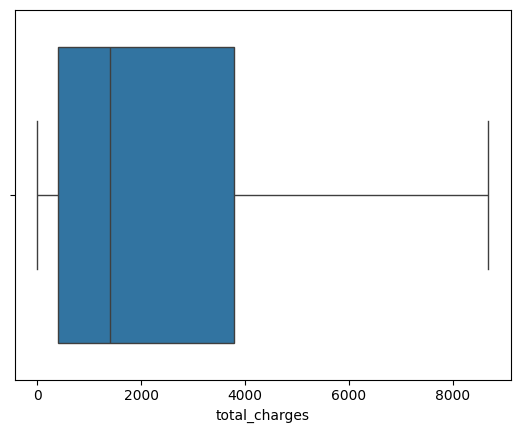

In [17]:
sns.boxplot(x='total_charges',data=df)

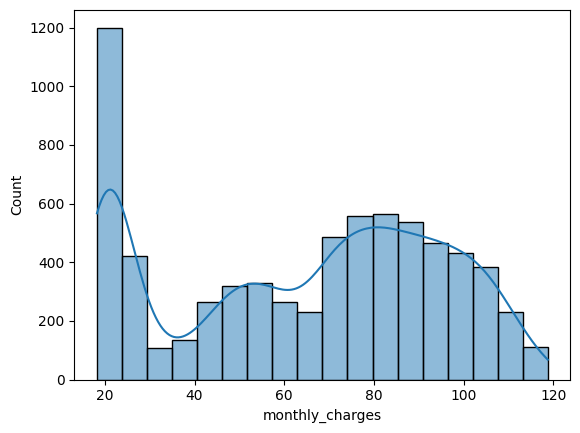

In [18]:
sns.histplot(x=df['monthly_charges'],kde=True)
plt.show()

### Observation

Monthly charges vary considerably across customers, suggesting the presence of different service plans and pricing structures.

<Axes: xlabel='monthly_charges'>

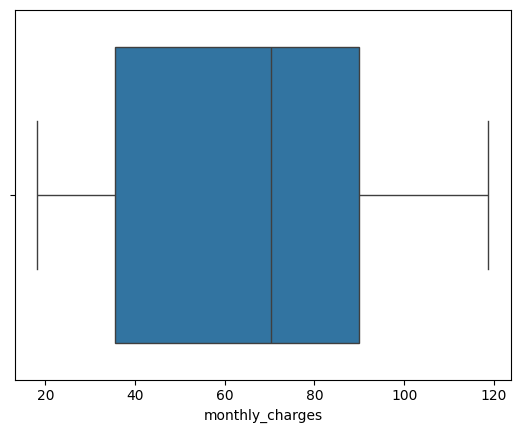

In [19]:
sns.boxplot(x='monthly_charges',data=df)

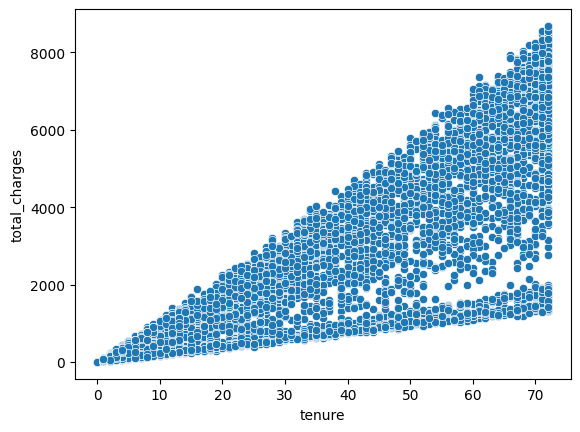

In [20]:
sns.scatterplot(x='tenure',y='total_charges',data=df)
plt.show()

### Observation

A strong positive relationship exists between tenure and total charges. Customers who stay longer with the company tend to accumulate higher total charges over time.

In [21]:
df['gender'].value_counts()


gender
Male      3555
Female    3488
Name: count, dtype: int64

In [22]:
df['contract'].value_counts(normalize=True)*100

contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64

### Observation

Month-to-Month contract customers exhibit significantly higher churn rates compared to One-Year and Two-Year contract customers.

In [23]:
df['payment_method'].value_counts()

payment_method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [24]:
t=df['payment_method'].value_counts(normalize=True)*100
t.round(1)

payment_method
Electronic check             33.6
Mailed check                 22.9
Bank transfer (automatic)    21.9
Credit card (automatic)      21.6
Name: proportion, dtype: float64

### Observation

Customers using Electronic Check show the highest churn rate, whereas customers using automatic payment methods demonstrate better retention.

In [25]:
df['internet_service'].value_counts()

internet_service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [26]:
t=df['internet_service'].value_counts(normalize=True)*100
t.round(1)

internet_service
Fiber optic    44.0
DSL            34.4
No             21.7
Name: proportion, dtype: float64

### Observation

Fiber Optic customers contribute the highest number of churned customers among all internet service categories.

In [27]:
df['churn'].value_counts(normalize=True)*100

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Observation

Approximately 26.5% of customers have churned, while 73.5% have remained with the company.

In [28]:
pd.crosstab(df['contract'],df['churn'])

churn,No,Yes
contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [29]:
pd.crosstab(df['internet_service'],df['churn'])

churn,No,Yes
internet_service,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [30]:
pd.crosstab(df['payment_method'],df['churn'])

churn,No,Yes
payment_method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


# Task 4: Customer Segmentation Visualization

## Objective

Segment customers based on tenure and analyze their distribution, spending behavior, and business value.

In [31]:
df['customer_segment']=pd.cut(df['tenure'],bins=[-1,12,36,72],labels=['0-12 months','13-36 months','37+months'])


In [32]:
df['customer_segment'].head()

0     0-12 months
1    13-36 months
2     0-12 months
3       37+months
4     0-12 months
Name: customer_segment, dtype: category
Categories (3, object): ['0-12 months' < '13-36 months' < '37+months']

In [33]:
df['customer_segment'].value_counts()

customer_segment
37+months       3001
0-12 months     2186
13-36 months    1856
Name: count, dtype: int64

In [34]:
df['customer_segment'].value_counts(normalize=True)*100

customer_segment
37+months       42.609683
0-12 months     31.037910
13-36 months    26.352407
Name: proportion, dtype: float64

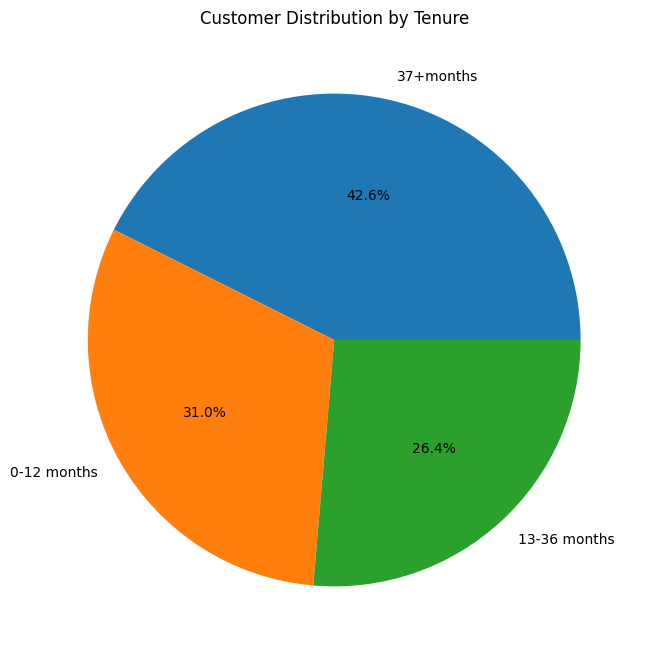

In [35]:
plt.figure(figsize=(8,8))

plt.pie(
    df['customer_segment'].value_counts(),
    labels=df['customer_segment'].value_counts().index,
    autopct='%1.1f%%'
)

plt.title('Customer Distribution by Tenure')
plt.show()

### Observation

Customers were segmented into 0–12 months, 13–36 months, and 37+ months tenure categories to understand customer lifecycle stages.

In [36]:
df['monthly_charges'].mean()

64.76169246059918

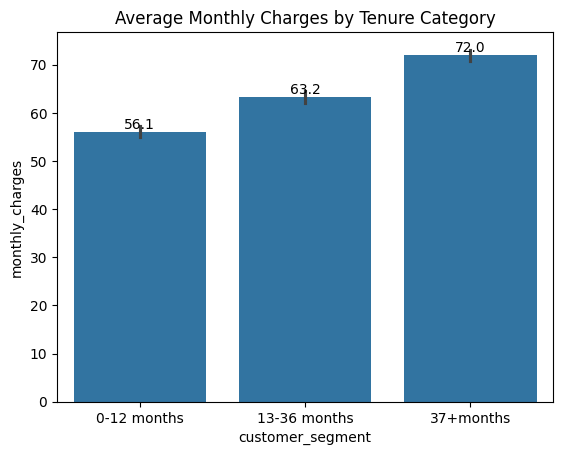

In [37]:
ax=sns.barplot(x='customer_segment',y='monthly_charges',data=df,estimator='mean')
for i in ax.containers:
    ax.bar_label(i, fmt='%.1f')

plt.title('Average Monthly Charges by Tenure Category')
plt.show()

### Observation

Average monthly charges increase with customer tenure. Long-term customers (37+ months) generate the highest monthly revenue.

### Business Insight

Long-term customers contribute more revenue and exhibit greater loyalty. Retaining customers beyond the first year can significantly improve customer lifetime value.

# Task 5: Advanced Analysis

## Objective

Perform deeper analysis to identify relationships between customer demographics, contract types, payment methods, and churn behavior.

In [38]:
print(df.groupby('customer_segment',observed=True)['monthly_charges'].sum().sort_values(ascending=False))

customer_segment
37+months       216098.20
0-12 months     122629.75
13-36 months    117388.65
Name: monthly_charges, dtype: float64


### Observation

Long-term customers generate the highest overall revenue and contribute significantly to the company's financial performance.

In [39]:
print(df.groupby('customer_segment',observed=True)['monthly_charges'].mean().sort_values(ascending=False))


customer_segment
37+months       72.008730
13-36 months    63.248195
0-12 months     56.097781
Name: monthly_charges, dtype: float64


In [40]:
print(df.groupby('customer_segment',observed=True)['churn'].count().sort_values(ascending=False))


customer_segment
37+months       3001
0-12 months     2186
13-36 months    1856
Name: churn, dtype: int64


In [41]:
pd.crosstab(df['customer_segment'],df['churn'])

churn,No,Yes
customer_segment,,
0-12 months,1149,1037
13-36 months,1382,474
37+months,2643,358


In [42]:
tt = pd.crosstab(df['gender'],df['churn'],normalize='index')*100
tt.round(1)

churn,No,Yes
gender,,
Female,73.1,26.9
Male,73.8,26.2


### Observation

Male and female customers exhibit nearly identical churn rates, indicating that gender has minimal influence on customer churn.

In [43]:
df['senior_citizen'].value_counts()

senior_citizen
0    5901
1    1142
Name: count, dtype: int64

In [44]:
tt = pd.crosstab(df['senior_citizen'],df['churn'],normalize='index')*100
tt.round(1)

churn,No,Yes
senior_citizen,,
0,76.4,23.6
1,58.3,41.7


### Observation

Senior citizens have a noticeably higher churn rate compared to non-senior customers, suggesting the need for targeted retention strategies.

In [45]:
c=pd.crosstab(df['payment_method'],df['churn'],normalize='index')*100
c.round(1)

churn,No,Yes
payment_method,,
Bank transfer (automatic),83.3,16.7
Credit card (automatic),84.8,15.2
Electronic check,54.7,45.3
Mailed check,80.9,19.1


### Observation

Electronic Check customers exhibit the highest churn rate. Further analysis shows that most Electronic Check users are enrolled in Month-to-Month contracts, which may contribute to the elevated churn levels.

In [46]:
c=pd.crosstab(df['contract'],df['churn'],normalize='index')*100
c.round(1)

churn,No,Yes
contract,,
Month-to-month,57.3,42.7
One year,88.7,11.3
Two year,97.2,2.8


### Observation

Customers on Month-to-Month contracts experience the highest churn rate, whereas Two-Year contract customers show the strongest retention.

In [47]:
pd.crosstab(
    df['payment_method'],
    df['contract'],
    normalize='index'
)*100

contract,Month-to-month,One year,Two year
payment_method,,,
Bank transfer (automatic),38.147668,25.323834,36.528497
Credit card (automatic),35.676741,26.149803,38.173456
Electronic check,78.224101,14.672304,7.103594
Mailed check,55.397022,20.905707,23.697270


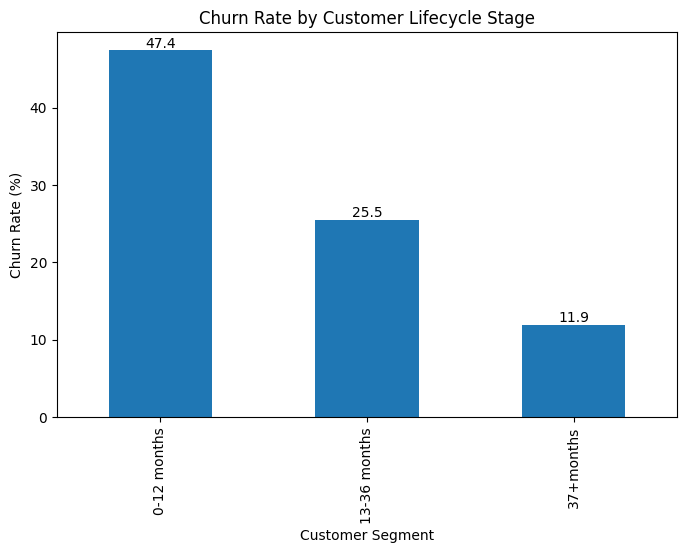

In [48]:
churn_rate = pd.crosstab(df['customer_segment'],df['churn'],normalize='index')*100
churn_rate = churn_rate.round(1)

ax = churn_rate['Yes'].plot(
    kind='bar',
    figsize=(8,5)
)

for i in ax.containers:
    ax.bar_label(i, fmt='%.1f')

plt.title('Churn Rate by Customer Lifecycle Stage')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Customer Segment')
plt.show()

### Observation

Customer churn is highest during the early stages of the customer lifecycle and decreases as customer tenure increases. Long-term customers are more loyal and valuable to the business.

In [49]:
df.corr(numeric_only=True) 

,senior_citizen,tenure,monthly_charges,total_charges
senior_citizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
monthly_charges,0.220173,0.247900,1.000000,0.651174
total_charges,0.103006,0.826178,0.651174,1.000000


<Axes: >

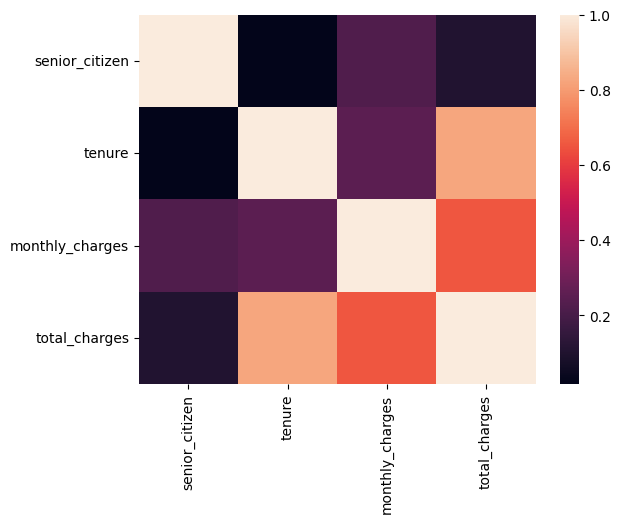

In [50]:
sns.heatmap(df.corr(numeric_only=True))

### Observation

The heatmap and correlation analysis indicate a strong positive relationship between `tenure` and `TotalCharges` (0.83), suggesting that customers who stay longer accumulate higher total charges over time. `MonthlyCharges` also shows a moderate positive correlation with `TotalCharges` (0.65), indicating that higher monthly plans contribute to greater overall spending. `SeniorCitizen` has a weak correlation with the other variables, suggesting limited direct influence on customer charges and tenure.

# Final Conclusion

The analysis identified customer tenure, contract type, payment method, and senior citizen status as important factors associated with customer churn. Month-to-Month customers and Electronic Check users exhibit the highest churn rates, while long-term customers generate higher revenue and demonstrate stronger loyalty. Focusing on customer retention during the first year and encouraging long-term contracts may help reduce churn and improve overall business performance.